In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

data = yf.download(
    "TCS.NS",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

[*********************100%***********************]  1 of 1 completed


In [ ]:
data = data[["Open", "High", "Low", "Close", "Volume"]]

print(data.head(10))

Price              Open         High          Low        Close   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2015-01-01  1283.500000  1283.500000  1270.500000  1272.775024   366830
2015-01-02  1275.500000  1295.474976  1275.300049  1289.724976   925740
2015-01-05  1290.500000  1299.949951  1262.324951  1270.125000  1754242
2015-01-06  1264.550049  1264.550049  1220.000000  1223.300049  2423784
2015-01-07  1235.000000  1239.574951  1203.724976  1208.849976  2636332
2015-01-08  1221.199951  1224.500000  1210.275024  1221.900024  1565408
2015-01-09  1227.500000  1259.949951  1225.000000  1256.150024  3197642
2015-01-12  1258.500000  1264.000000  1240.125000  1254.849976  1596006
2015-01-13  1260.000000  1265.199951  1240.050049  1248.949951  1468432
2015-01-14  1258.000000  1265.900024  1250.250000  1260.974976  1787096


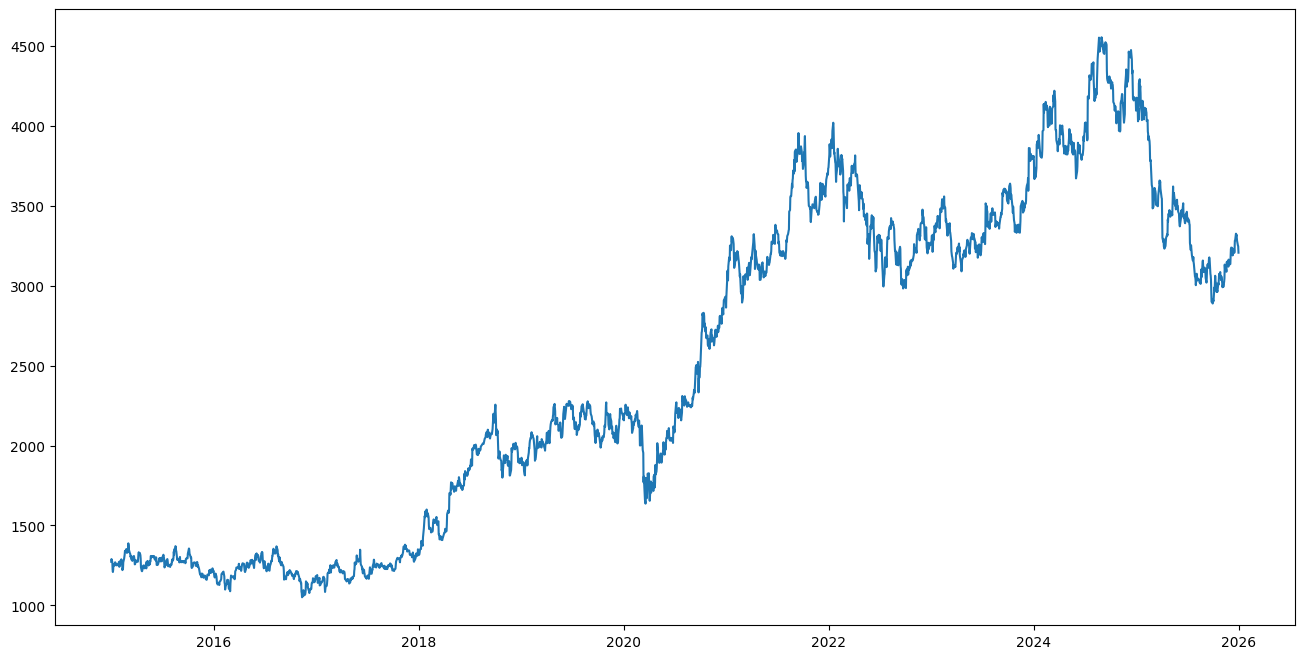

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(data['Close'], label='Closing Price')

Classification Problem : Buy (+1) or sell (-1) the stock





In [ ]:
data['Open - Close'] = data['Open'] - data['Close']
data['High - Low'] = data['High'] - data['Low']
data = data.dropna()

Input Features to predict whether customer should buy or sell the stock

In [ ]:
X = data[['Open - Close', 'High - Low']]
X.head()

Price,Open - Close,High - Low
Ticker,,
Date,,
2015-01-01,10.724976,13.000000
2015-01-02,-14.224976,20.174927
2015-01-05,20.375000,37.625000
2015-01-06,41.250000,44.550049
2015-01-07,26.150024,35.849976


Intention is to store +1 for the signal and -1 for the sell signal. The target variable is 'Y' for classification task.

In [ ]:
Y = np.where(data['Close'].shift(-1)>data['Close'],1,-1)

In [ ]:
Y

array([[ 1],
       [-1],
       [-1],
       ...,
       [-1],
       [-1],
       [-1]])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state = 44)
y_train = y_train.ravel()
y_test = y_test.ravel()

Implementation of KNN Classfier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

#using gridsearch to find the best parameter
params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn = neighbors.KNeighborsClassifier()
model = GridSearchCV(knn, params, cv=5)

#fit the model
model.fit(X_train, y_train)

# Accuracy Score
accuracy_train = accuracy_score(y_train, model.predict(X_train))
accuracy_test = accuracy_score(y_test, model.predict(X_test))

print ('Train_data Accuracy: %.2f' %accuracy_train)
print ('Test_data Accuracy: %.2f' %accuracy_test)


Train_data Accuracy: 0.76
Test_data Accuracy: 0.48


In [ ]:
prediction_classification = model.predict(X_test)

In [ ]:
actual_predicted_data = pd.DataFrame({'Actual Class':y_test, 'Predicted Class': prediction_classification})

In [ ]:
actual_predicted_data.head(10)

,Actual Class,Predicted Class
0,-1,1
1,-1,-1
2,1,-1
3,-1,-1
4,1,1
5,1,-1
6,1,-1
7,1,-1
8,-1,-1
9,-1,-1


Regression Problem : KNN

In [ ]:
y = data['Close']

In [ ]:
y

Ticker,TCS.NS
Date,
2015-01-01,1272.775024
2015-01-02,1289.724976
2015-01-05,1270.125000
2015-01-06,1223.300049
2015-01-07,1208.849976
...,...
2025-12-24,3319.000000
2025-12-26,3280.000000
2025-12-29,3251.500000


Implementation of KNN Regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.25, random_state=44)

#using gridsearch to find the best parameter
params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn_reg = neighbors.KNeighborsRegressor()
model_reg = GridSearchCV(knn_reg, params, cv=5)

#fit the model and make predictions
model_reg.fit(X_train_reg, y_train_reg)
predictions = model_reg.predict(X_test_reg)

In [ ]:
y_test_reg = np.asarray(y_test_reg).ravel()
predictions = np.asarray(predictions).ravel()

valid = pd.DataFrame({
    'Actual Close': y_test_reg,
    'Predicted Close value': predictions
})

valid.head(10)

,Actual Close,Predicted Close value
0,3144.699951,2073.866683
1,2830.000000,2946.343335
2,3057.350098,3216.571647
3,1912.949951,2157.063330
4,1279.574951,1346.016659
5,1692.824951,3352.656689
6,3497.100098,3439.526668
7,3331.550049,1479.108333
8,3148.000000,1953.920011
9,1552.925049,2656.053328


In [ ]:
#rmse
rms=np.sqrt(np.mean(np.power((np.array(y_test)-np.array(predictions)),2)))
rms

np.float64(2602.5208301405414)

In [ ]:
valid = pd.DataFrame({'Actual Close':y_test_reg, 'Predicted Close value': predictions})

In [ ]:
valid.head(10)

,Actual Close,Predicted Close value
0,3144.699951,2073.866683
1,2830.000000,2946.343335
2,3057.350098,3216.571647
3,1912.949951,2157.063330
4,1279.574951,1346.016659
5,1692.824951,3352.656689
6,3497.100098,3439.526668
7,3331.550049,1479.108333
8,3148.000000,1953.920011
9,1552.925049,2656.053328
